# Safety experiment plots, averaged over seeds

Loads every seed in `results_dir` saved for the chosen `regressor_name` and `n`
(files `simulations_safety_model{regressor_name}_{seed}_seed_n_{n}_martingales.pkl`, written by
`safety_simulations.py`). Each plot shows the mean across seeds; when there is more than one seed,
a shaded band shows ±1 standard deviation.

### Changelog
**2026-10-01: rewritten to average over seeds**
- Replaced the hard-coded absolute path for seed 1 with a glob over all seeds for the chosen `regressor_name` and `n`. The seed is parsed from the filename.
- Removed the `seed` / `single_seed` config and the unused, broken `load_martingales()` (it indexed `mean_martingales[strategy]` before creating it).
- Martingales, lambdas, Wasserstein distances and risk differences are stacked across seeds and plotted as mean ± 1 sd.
- **x-axis changed:** all plots now use the real time index t. Updates happen at `t = n_init + k·batch` (see `ML_e_process.martingales`). Previously, lambdas, Wasserstein distances and risk differences were plotted against `index × batch`, starting at 0. That shifted them left by `n_init` compared with the martingales.
- Added a dashed `1/alpha` rejection threshold to the martingale plot.
- Lambdas are still divided by 5 (`lambda_scale`), as in the original cell 5.
- Wasserstein distances are handled both as plain floats (current format) and as `(distance, reference)` pairs (the format the old cell 11 expected).
- Added a final 2×2 figure (martingales, lambdas, Wasserstein distance, risk difference), saved as a PDF next to the notebook.
- Removed the exploratory cells that only displayed raw objects (`all_martingales[2]`, `len(...)` prints).

**Rollback:** the original cells are copied verbatim in the appendix at the bottom of the notebook. You can also use `git diff` / `git checkout` on this file, but note that the notebook already had uncommitted changes before this rewrite.

In [1]:
from pathlib import Path
import pickle
import re

import matplotlib.pyplot as plt
import numpy as np


alpha = 0.05
n = 20000#15000#9000#5001#5000#2599#899#399#299#799#
regressor_name = "nn" #"tm" #"nn"
coordinate = 0
batch_list = [5, 10, 20]
smallest_batch = min(batch_list)
strategy = "sign" #"coin_betting"# #"coin_betting"#
pretraining_percentage = 1          # must match --pretraining_percentage used in safety_simulations.py
n_init = int(n * pretraining_percentage / 100.0)
lambda_scale = 5.0                   # lambdas are divided by this (as in the original notebook)

results_dir = Path("../../results/csv/safety_simulations")

In [2]:
def load_runs():
    """Load every seed for (regressor_name, n). Returns {seed: (martingales, lambdas, distances, errors)}."""
    pattern = re.compile(
        rf"simulations_safety_model_{re.escape(regressor_name)}_(\d+)_seed_n_{n}_strategy_{re.escape(strategy)}_martingales\.pkl"
    )
    runs = {}
    for file in results_dir.iterdir():
        match = pattern.fullmatch(file.name)
        if match:
            with open(file, "rb") as f:
                runs[int(match.group(1))] = pickle.load(f)
    if not runs:
        raise FileNotFoundError(f"No files for model={regressor_name}, n={n} in {results_dir.resolve()}")
    runs = dict(sorted(runs.items()))
    print(f"loaded {len(runs)} seed(s): {list(runs)}")
    return runs


def stack(sequences):
    """Stack per-seed sequences into an array (n_seeds, T, ...), truncating to the shortest one."""
    arrays = [np.asarray(s, dtype=float) for s in sequences]
    length = min(a.shape[0] for a in arrays)
    if any(a.shape[0] != length for a in arrays):
        print(f"warning: sequences have different lengths, truncating to {length}")
    return np.stack([a[:length] for a in arrays])


runs = load_runs()
seeds = list(runs)

martingales = {
    b: stack([runs[s][0][strategy][b][coordinate] for s in seeds]) for b in batch_list
}
lambdas = {
    b: stack([[d["lambda"] / lambda_scale for d in runs[s][1][coordinate][b][strategy]] for s in seeds])
    for b in batch_list
}
distances = stack([runs[s][2] for s in seeds])   # (n_seeds, T) or (n_seeds, T, 2) with a reference column
risk_diffs = stack([runs[s][3] for s in seeds])


def update_times(length, batch):
    """Time index of the k-th update for a given batch size: n_init + (k + 1) * batch."""
    return n_init + batch * np.arange(1, length + 1)

loaded 10 seed(s): [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]


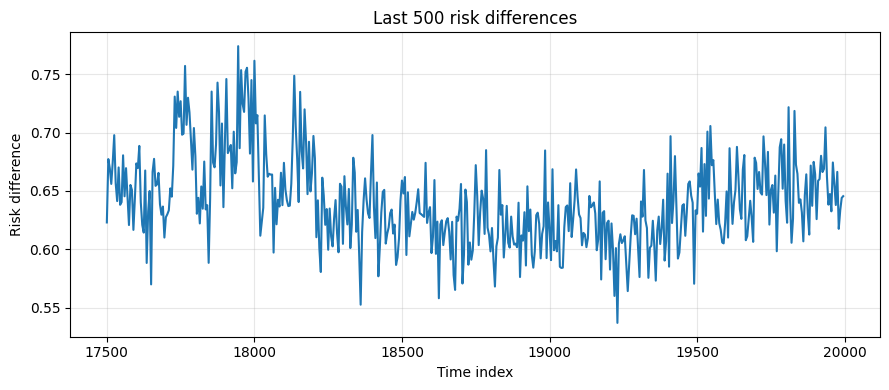

In [3]:
vals = risk_diffs[0][-500:]
t = update_times(len(risk_diffs[0]), smallest_batch)[-500:]

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(t, vals)
ax.set(xlabel="Time index", ylabel="Risk difference", title="Last 500 risk differences")
ax.grid(True, alpha=0.3)
plt.tight_layout()

In [4]:
def plot_mean_band(ax, t, values, nstd=0.5, label=None, **kwargs):
    """Plot the mean over seeds (axis 0) and a ±1 sd band when there are several seeds."""
    mean = values.mean(axis=0)
    line, = ax.plot(t, mean, label=label, **kwargs)
    if values.shape[0] > 1:
        sd = values.std(axis=0)
        ax.fill_between(t, mean - nstd*sd, mean + nstd*sd, color=line.get_color(), alpha=0.2, linewidth=0)


def seeds_note():
    return f"mean over {len(seeds)} seed(s)"


def plot_martingales(ax, nstd=1):
    for b in batch_list:
        values = martingales[b]
        plot_mean_band(ax, np.arange(values.shape[1]), values, label=f"batch size {b}", nstd=nstd)
    #ax.axhline(1 / alpha, color="gray", linestyle="--", linewidth=1, label=r"$1/\alpha$")
    ax.set(title=f"Coin betting martingales (feature {coordinate}, {seeds_note()})",
           xlabel="Time index", ylabel="Martingale value")
    ax.legend(title="Batch")
    ax.grid(True, alpha=0.3)


def plot_lambdas(ax):
    for b in batch_list:
        values = lambdas[b]
        plot_mean_band(ax, update_times(values.shape[1], b), values, label=f"batch size {b}")
    ax.set(title=f"Selected lambda by batch (feature {coordinate}, {seeds_note()})",
           xlabel="Time index", ylabel="Lambda value")
    ax.legend(title="Batch")
    ax.grid(True, alpha=0.3)


def plot_wasserstein(ax):
    t = update_times(distances.shape[1], smallest_batch)
    if distances.ndim == 3:  # (distance, reference) pairs
        plot_mean_band(ax, t, distances[:, :, 0], label="Wasserstein distance")
        plot_mean_band(ax, t, distances[:, :, 1], label="Reference")
        ax.legend()
    else:
        plot_mean_band(ax, t, distances)
    ax.set(title=f"Wasserstein distance, estimated vs. true conditional ({seeds_note()})",
           xlabel="Time index", ylabel="Distance")
    ax.grid(True, alpha=0.3)


def plot_risk_difference(ax):
    t = update_times(risk_diffs.shape[1], smallest_batch)
    plot_mean_band(ax, t, risk_diffs)
    ax.set(title=rf"Risk difference $\hat m$ vs. $m_0$ ({seeds_note()})",
           xlabel="Time index", ylabel="Test risk difference")
    ax.grid(True, alpha=0.3)

## Martingales

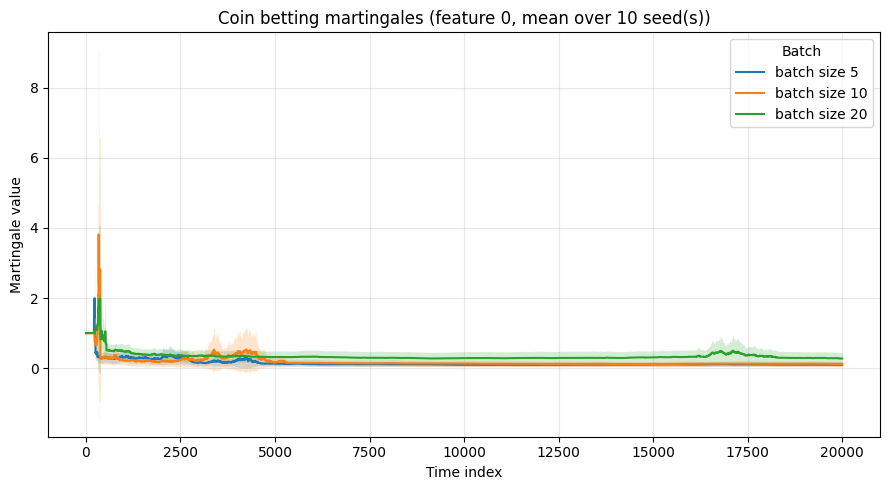

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_martingales(ax, nstd=0.5)
plt.tight_layout()

## Selected lambdas

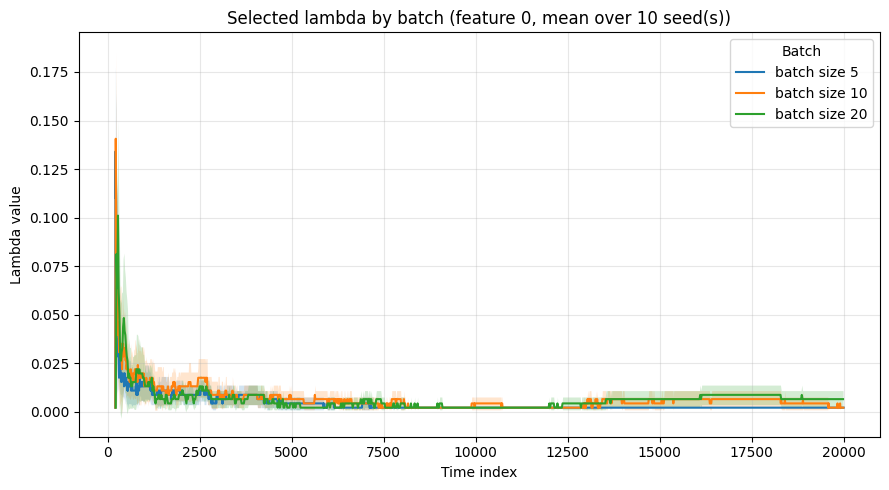

In [6]:
fig, ax = plt.subplots(figsize=(9, 5))
plot_lambdas(ax)
plt.tight_layout()

## Wasserstein distance

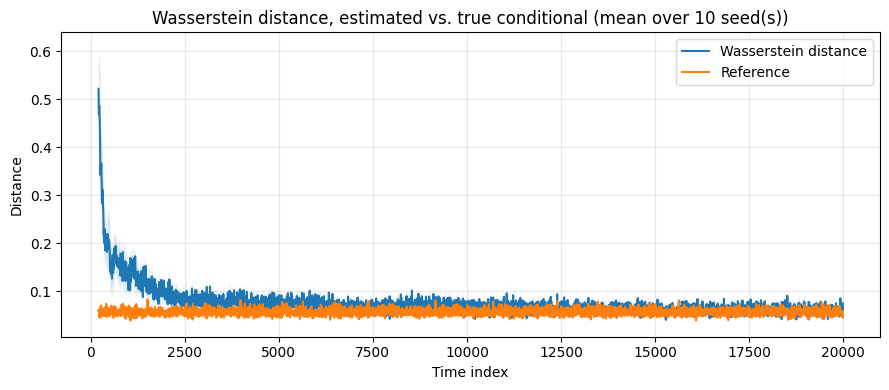

In [7]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_wasserstein(ax)
plt.tight_layout()

## Risk difference

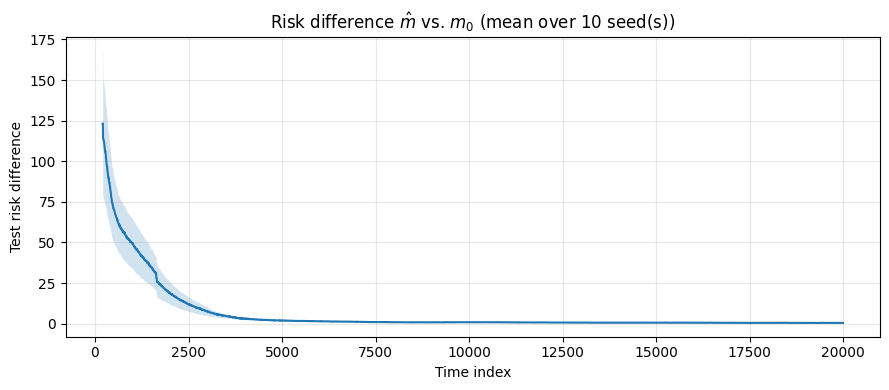

In [8]:
fig, ax = plt.subplots(figsize=(9, 4))
plot_risk_difference(ax)
plt.tight_layout()

## Summary figure: martingales, lambdas, Wasserstein distance, risk difference

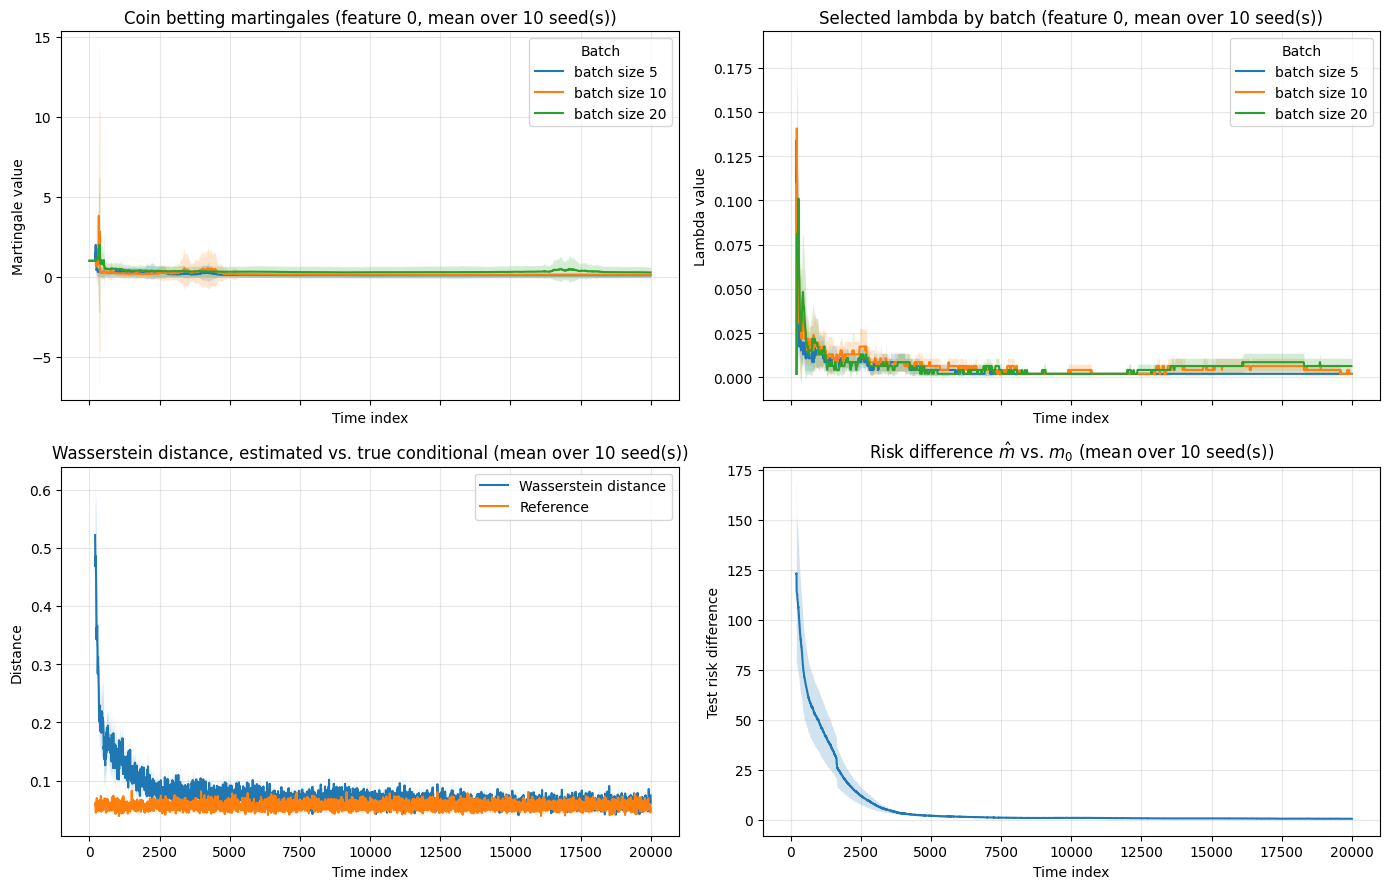

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex=True)
plot_martingales(axes[0, 0])
plot_lambdas(axes[0, 1])
plot_wasserstein(axes[1, 0])
plot_risk_difference(axes[1, 1])
plt.tight_layout()
fig.savefig(f"safety_summary_model{regressor_name}_n{n}.pdf", bbox_inches="tight")

## Appendix: original notebook cells (before the 2026-10-01 rewrite)

Paste any of these back into a code cell to restore the old single-seed behaviour.

**Original cell 0**

```python
from pathlib import Path
import pickle

import matplotlib.pyplot as plt
import numpy as np


alpha = 0.05
n = 8000
regressor_name = "nn"
coordinate = 0
batch_list = [5, 10, 20]
smallest_batch = min(batch_list)
seed = 1
single_seed = False
strategy = "coin betting"



results_dir = Path("../results/csv/safety_simulations")
```

**Original cell 1**

```python
# filename = f"simulations_safety_model{regressor_name}_{seed}_seed_martingales.pkl"
# file = results_dir / filename
# with open(file, "rb") as f:
#     all_martingales = pickle.load(f)
```

**Original cell 2**

```python
file = f"/home/michele/Documents/testing_conditional_independence/shaer_replication/ecrt/results/csv/safety_simulations/simulations_safety_modelnn_1_seed_n_{n}_martingales.pkl"
with open(file, "rb") as f:
    all_martingales = pickle.load(f)
```

**Original cell 3**

```python
all_martingales[0]['coin betting']#[2][0]
```

**Original cell 4**

```python
martingales_by_batch = all_martingales[0]["coin betting"]
fig, ax = plt.subplots(figsize=(9, 5))
for batch in sorted(martingales_by_batch):
    values = np.asarray(martingales_by_batch[batch][coordinate])
    ax.plot(np.arange(values.size), values, label=f"batch size {batch}")

ax.set(title=f"Coin betting martingales (seed {seed}, feature {coordinate})",
       xlabel="Time index", ylabel="Martingale value")
ax.legend(title="Batch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
```

**Original cell 5**

```python
#np.array(
lambdas = {}
for b in batch_list:
    lambdas[b] = [d["lambda"]/5.0 for d in all_martingales[1][0][b]['coin betting']]
```

**Original cell 6**

```python
fig, ax = plt.subplots(figsize=(9, 5))
for batch in batch_list:
    values = np.asarray(lambdas[batch])
    ax.plot(np.arange(values.size) * batch, values, label=f"batch size {batch}")

ax.set(title=f"Selected lambda by batch (seed {seed}, feature {coordinate})",
       xlabel="Time index (i × batch size)", ylabel="Lambda value")
ax.legend(title="Batch")
ax.grid(True, alpha=0.3)
plt.tight_layout()
```

**Original cell 7**

```python
def load_martingales():
    files = []
    if single_seed:
        file = results_dir / f"simulations_safety_model{regressor_name}_{seed}_seed_martingales.pkl"
        files.append(file)
        if not file.exists():
            raise FileNotFoundError(f"No martingale file found  in {results_dir}")
    else:
        files = sorted(
            results_dir.glob(
                f"simulations_safety_model{regressor_name}_*_seed_martingales.pkl"
            )
        )
        if not files:
            raise FileNotFoundError(f"No martingale files found  in {results_dir}")

    all_martingales = []
    for file in files:
        with open(file, "rb") as f:
            all_martingales.append(pickle.load(f))


    mean_martingales = {}
    for batch in all_martingales[0][strategy]:
        mean_martingales[batch] = {}
        for j in all_martingales[0][strategy][batch]:
            arrays = [m[strategy][batch][j] for m in all_martingales]
            mean_martingales[strategy][batch][j] = np.mean(arrays, axis=0)

    print(f"loaded {len(all_martingales)} seeds")
    return mean_martingales
```

**Original cell 8**

```python
all_martingales[2]
```

**Original cell 9**

```python
print(len(all_martingales[2]))
print(len(lambdas[5]))
print(len(lambdas[10]))
```

**Original cell 10**

```python
all_martingales[2]
```

**Original cell 11**

```python
plt.figure(figsize=(9, 4))

was = [p[0] for p in all_martingales[2]]
ref = [p[1] for p in all_martingales[2]]

plt.plot(np.arange(len(was)) * smallest_batch, was, label=f"Wasserstein distance")
plt.plot(np.arange(len(ref)) * smallest_batch, ref, label=f"Reference")

plt.legend(title="Batch size")
plt.title("all_martingales[2]")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
```

**Original cell 12**

```python
print(len(lambdas[5]))
print(len(all_martingales[2]))
```

**Original cell 13**

```python
all_martingales[3]
```

**Original cell 14**

```python
plt.figure(figsize=(9, 4))

seq = all_martingales[3]

plt.plot(np.arange(len(seq)) * smallest_batch, seq, label=f"Risk difference ")

plt.legend(title="Batch size")
plt.title("Risk difference m_hat vs. m_0")
plt.xlabel("Index")
plt.ylabel("Value")
plt.grid(True, alpha=0.3)
plt.tight_layout()
```